/tmp/ipykernel_3834867/3115900109.py:70: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X_test[y_test == 1][:, 0], X_test[y_test == 1][:, 1], label="Tgt, C_1", edgecolors='k', color='blue', marker='x', alpha=0.9)
/tmp/ipykernel_3834867/3115900109.py:82: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(


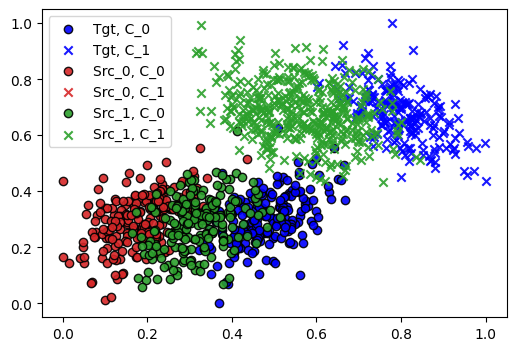

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.model_selection import train_test_split

# Set seed for reproducibility
np.random.seed(42)

# Set seed for reproducibility
np.random.seed(42)

def generate_gaussian_data(mean, cov, num_samples, label):
    """Generate data from a multivariate Gaussian distribution."""
    data = np.random.multivariate_normal(mean, cov, num_samples)
    labels = np.full(num_samples, label)
    return data, labels

# Define the parameters for the three domains
# Shift the means between domains but keep covariances similar to simulate covariate shift
domains = [
    {"mean_class_0": [2, 2], "mean_class_1": [6, 6], 
     "cov_class_0": [[1, 0.5], [0.5, 1]], "cov_class_1": [[1, -0.5], [-0.5, 1]]},
    
    {"mean_class_0": [4, 2], "mean_class_1": [8, 6], 
     "cov_class_0": [[1, 0.5], [0.5, 1]], "cov_class_1": [[1, -0.5], [-0.5, 1]]},
    
    {"mean_class_0": [6, 2], "mean_class_1": [10, 6], 
     "cov_class_0": [[1, 0.5], [0.5, 1]], "cov_class_1": [[1, -0.5], [-0.5, 1]]}
]

# Generate data for each domain
domain_data = []
domain_labels = []
num_samples_per_class = 200

for domain in domains:
    data_class_0, labels_class_0 = generate_gaussian_data(domain["mean_class_0"], domain["cov_class_0"], num_samples_per_class, label=0)
    data_class_1, labels_class_1 = generate_gaussian_data(domain["mean_class_1"], domain["cov_class_1"], num_samples_per_class, label=1)
    
    domain_data.append(np.vstack([data_class_0, data_class_1]))
    domain_labels.append(np.hstack([labels_class_0, labels_class_1]))

# Concatenate all domain data to compute global min and max
all_data = np.vstack(domain_data)
data_min = all_data.min(axis=0)
data_max = all_data.max(axis=0)

# Apply min-max normalization to each domain
domain_data = [(data - data_min) / (data_max - data_min) for data in domain_data]

# Reconstruct training and test splits after normalization
X_train = np.vstack([domain_data[0], domain_data[1]])
y_train = np.hstack([domain_labels[0], domain_labels[1]])
X_test = domain_data[2]
y_test = domain_labels[2]
plt.figure(figsize=(6, 4))
# # Visualize the data to check the covariate shift across domains
# colors = ['r', 'g', 'b']
# plt.figure(figsize=(6, 4))
# for i, (data, labels) in enumerate(zip(domain_data, domain_labels)):
#     plt.scatter(data[labels == 0][:, 0], data[labels == 0][:, 1], label=f"D_{i}, C_0", alpha=0.7, color=colors[i], marker='o')
#     plt.scatter(data[labels == 1][:, 0], data[labels == 1][:, 1], label=f"D_{i}, C_1", alpha=0.7, color=colors[i], marker='x')


# Plot the test data points (Domain 3)
plt.scatter(X_test[y_test == 0][:, 0], X_test[y_test == 0][:, 1], label="Tgt, C_0", edgecolors='k', color='blue', marker='o', alpha=0.9)
plt.scatter(X_test[y_test == 1][:, 0], X_test[y_test == 1][:, 1], label="Tgt, C_1", edgecolors='k', color='blue', marker='x', alpha=0.9)


domain_train = np.zeros(len(X_train), dtype=int)
domain_train[200:] = 1  # Assume second 200 are Domain 1

domain_colors = ["tab:red", "tab:green"]
class_markers = ["o", "x"]

for d in (0, 1):  # domains
    for c in (0, 1):  # classes
        idx = (domain_train == d) & (y_train == c)
        plt.scatter(
            X_train[idx, 0],
            X_train[idx, 1],
            color=domain_colors[d],
            marker=class_markers[c],
            edgecolors='k',
            label=f"Src_{d}, C_{c}",
            alpha=0.9
        )

plt.legend()

# plt.title('Covariate Shift Across Domains for Class 0 and Class 1')
# plt.show()
plt.savefig("syntheticdata.pdf")

In [2]:
v = []
for i in np.arange(0, 1, 0.01):
    for j in np.arange(0, 1, 0.01):
        v.append([i, j])
v = np.array(v)
v_tensor = torch.tensor(v, dtype=torch.float32)

In [3]:
# Convert data to PyTorch tensors
X_train_tensor = torch.Tensor(X_train)
y_train_tensor = torch.Tensor(y_train).long()
X_test_tensor = torch.Tensor(X_test)
y_test_tensor = torch.Tensor(y_test).long()

In [4]:

# Define the MLP model
class SimpleMLP(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(SimpleMLP, self).__init__()
        self.featurizer = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
        )
        self.classifier = nn.Linear(hidden_size, 2)
    
    def forward(self, x):
        features = self.featurizer(x)
        logits = self.classifier(features)
        return logits, features


In [5]:
# Initialize model, loss function, and optimizer
input_size = X_train.shape[1]
hidden_size = 16
output_size = 2
model_a = SimpleMLP(input_size, hidden_size, output_size)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_a.parameters(), lr=0.001)

# Training the model on first two domains
num_epochs = 100
losses_model_a = []
for epoch in range(num_epochs):
    model_a.train()
    outputs, _ = model_a(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    losses_model_a.append(loss.item())
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")



Epoch [10/100], Loss: 0.6802
Epoch [20/100], Loss: 0.6718
Epoch [30/100], Loss: 0.6633
Epoch [40/100], Loss: 0.6532
Epoch [50/100], Loss: 0.6412
Epoch [60/100], Loss: 0.6266
Epoch [70/100], Loss: 0.6083
Epoch [80/100], Loss: 0.5856
Epoch [90/100], Loss: 0.5580
Epoch [100/100], Loss: 0.5252


In [6]:
accs = []
for i in range(10):
    # Evaluate the model on the third domain
    model_a.eval()
    with torch.no_grad():
        test_outputs, _ = model_a(X_test_tensor)
        _, predicted = torch.max(test_outputs, 1)
        accuracy = (predicted == y_test_tensor).float().mean()
        accs.append(accuracy.item())
        
print(f"Test Accuracy on third domain: {np.mean(accs) * 100:.2f}%")

Test Accuracy on third domain: 82.75%


In [7]:
def rbf_kernel(features, gamma=None):
    """Compute the RBF (Gaussian) kernel matrix."""
    pairwise_sq_dists = torch.cdist(features, features, p=2).pow(2)
    if gamma is None:
        gamma = 1.0 / features.size(1)  # Default gamma is 1 / feature_dim
    kernel = torch.exp(-gamma * pairwise_sq_dists)
    return kernel

def diversity_loss(features, gamma=0.03):
    """Compute the DPP-based diversity loss."""
    kernel_matrix = rbf_kernel(features, gamma=gamma)
    # Add a small value to the diagonal for numerical stability
    kernel_matrix += torch.eye(kernel_matrix.size(0)).to(features.device) * 1e-6
    loss = -torch.logdet(kernel_matrix)
    return loss

In [8]:
X_train.shape

(800, 2)

In [9]:
# Initialize model, loss function, and optimizer
input_size = X_train.shape[1]
hidden_size = 64
output_size = 2
model_b = SimpleMLP(input_size, hidden_size, output_size)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_b.parameters(), lr=0.001)

# Set the weight for the DPP regularization term
alpha = 0.5  # You can adjust this value

# Training the model on first two domains with DPP regularization
num_epochs = 100
losses_model_b = []
for epoch in range(num_epochs):
    model_b.train()

    # Forward pass
    outputs, feats = model_b(X_train_tensor)
    # Compute cross-entropy loss
    loss_ce = criterion(outputs, y_train_tensor)
    # Compute diversity loss using DPP regularization
    loss_dpp = diversity_loss(X_train_tensor, gamma=0.1)

    # Combine cross-entropy loss with diversity loss
    loss = alpha * loss_ce + (1- alpha) * loss_dpp
    losses_model_b.append(loss_ce.item())

    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss_ce.item():.4f}")


Epoch [10/100], Loss: 0.6575
Epoch [20/100], Loss: 0.6162
Epoch [30/100], Loss: 0.5609
Epoch [40/100], Loss: 0.4869
Epoch [50/100], Loss: 0.3963
Epoch [60/100], Loss: 0.2996
Epoch [70/100], Loss: 0.2133
Epoch [80/100], Loss: 0.1479
Epoch [90/100], Loss: 0.1039
Epoch [100/100], Loss: 0.0767


In [10]:
from matplotlib.colors import ListedColormap

# Define custom color map: class 0 = yellow, class 1 = gray
fixed_cmap = ListedColormap(['gray', 'yellow'])

In [11]:
accs2 = []
for i in range(10):
    # Evaluate the model on the third domain
    model_b.eval()
    with torch.no_grad():
        test_outputs, _ = model_b(X_test_tensor)
        _, predicted = torch.max(test_outputs, 1)
        accuracy = (predicted == y_test_tensor).float().mean()
        accs2.append(accuracy.item())
print(f"Test Accuracy on third domain: {np.mean(accs2) * 100:.2f}%")
        

Test Accuracy on third domain: 92.75%


/tmp/ipykernel_3834867/711605159.py:43: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X_test[y_test == 1][:, 0], X_test[y_test == 1][:, 1], label="Tgt, C_1", edgecolors='k', color='blue', marker='x', alpha=0.9)
/tmp/ipykernel_3834867/711605159.py:55: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(


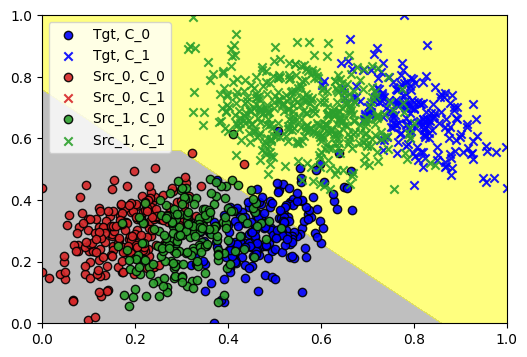

In [12]:
x_min, x_max = X_train[:, 0].min() - 1, X_test[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_test[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

# Flatten the grid to pass through the model
grid = np.c_[xx.ravel(), yy.ravel()]
grid_tensor = torch.Tensor(grid)
plt.figure(figsize=(6, 4))
# Get the model's predictions for each point in the grid
model_a.eval()
with torch.no_grad():
    logits, _ = model_a(grid_tensor)       # shape (N, num_classes)
    _, preds = torch.max(logits, 1)      # get class labels 0 or 1
    Z = preds.reshape(xx.shape).numpy()

model_a.eval()
with torch.no_grad():
    logits_v, _ = model_a(v_tensor)          # shape: (N, num_classes)
    _, preds = torch.max(logits_v, 1)      # get predicted class: 0 or 1
    preds_np = preds.numpy()
    
# Plot the decision boundary
plt.contourf(xx, yy, Z, alpha=0.5,levels=1, cmap=fixed_cmap)
# plt.scatter(
#     v[:, 0], v[:, 1],
#     c=preds_np,
#     cmap='coolwarm',         # or any categorical colormap like 'bwr', 'tab10'
#     s=5,
#     marker='*',
#     alpha=0.5,
#     edgecolors='none',
#     label='Predicted v'
# )

# Formatting
plt.xlim(0, 1)
plt.ylim(0, 1)

# Plot the test data points (Domain 3)
plt.scatter(X_test[y_test == 0][:, 0], X_test[y_test == 0][:, 1], label="Tgt, C_0", edgecolors='k', color='blue', marker='o', alpha=0.9)
plt.scatter(X_test[y_test == 1][:, 0], X_test[y_test == 1][:, 1], label="Tgt, C_1", edgecolors='k', color='blue', marker='x', alpha=0.9)


domain_train = np.zeros(len(X_train), dtype=int)
domain_train[200:] = 1  # Assume second 200 are Domain 1

domain_colors = ["tab:red", "tab:green"]
class_markers = ["o", "x"]

for d in (0, 1):  # domains
    for c in (0, 1):  # classes
        idx = (domain_train == d) & (y_train == c)
        plt.scatter(
            X_train[idx, 0],
            X_train[idx, 1],
            color=domain_colors[d],
            marker=class_markers[c],
            edgecolors='k',
            label=f"Src_{d}, C_{c}",
            alpha=0.9
        )

plt.legend()
# plt.title('Decision Boundary on Domain 3 (Test Domain)')
plt.savefig("model_a.pdf")


/tmp/ipykernel_3834867/736218979.py:39: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X_test[y_test == 1][:, 0], X_test[y_test == 1][:, 1], label="Tgt, C_1", edgecolors='k', color='blue', marker='x', alpha=0.9)
/tmp/ipykernel_3834867/736218979.py:51: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(


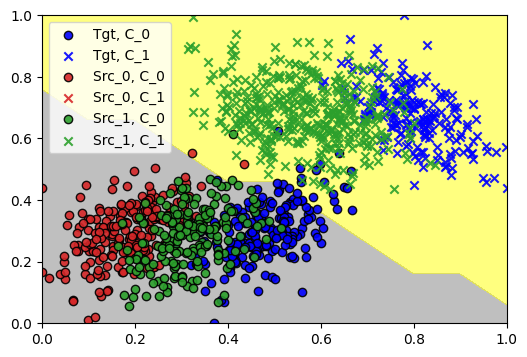

In [13]:
x_min, x_max = X_train[:, 0].min() - 1, X_test[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_test[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

# Flatten the grid to pass through the model
grid = np.c_[xx.ravel(), yy.ravel()]
grid_tensor = torch.Tensor(grid)
plt.figure(figsize=(6, 4))
# Get the model's predictions for each point in the grid
model_b.eval()
with torch.no_grad():
    logits, _ = model_b(grid_tensor)       # shape (N, num_classes)
    _, preds = torch.max(logits, 1)      # get class labels 0 or 1
    Z = preds.reshape(xx.shape).numpy()

model_b.eval()
with torch.no_grad():
    logits_v, _ = model_b(v_tensor)          # shape: (N, num_classes)
    _, preds = torch.max(logits_v, 1)      # get predicted class: 0 or 1
    preds_np = preds.numpy()
    
# Plot the decision boundary
plt.contourf(xx, yy, Z, levels=1, alpha=0.5, cmap=fixed_cmap)
# plt.scatter(
#     v[:, 0], v[:, 1],
#     c=preds_np,
#     cmap='coolwarm',         # or any categorical colormap like 'bwr', 'tab10'
#     s=5,
#     marker='*',
#     alpha=0.5,
#     edgecolors='none',
#     label='Predicted v'
# )

# Plot the test data points (Domain 3)
plt.scatter(X_test[y_test == 0][:, 0], X_test[y_test == 0][:, 1], label="Tgt, C_0", edgecolors='k', color='blue', marker='o', alpha=0.9)
plt.scatter(X_test[y_test == 1][:, 0], X_test[y_test == 1][:, 1], label="Tgt, C_1", edgecolors='k', color='blue', marker='x', alpha=0.9)


domain_train = np.zeros(len(X_train), dtype=int)
domain_train[200:] = 1  # Assume second 200 are Domain 1

domain_colors = ["tab:red", "tab:green"]
class_markers = ["o", "x"]

for d in (0, 1):  # domains
    for c in (0, 1):  # classes
        idx = (domain_train == d) & (y_train == c)
        plt.scatter(
            X_train[idx, 0],
            X_train[idx, 1],
            color=domain_colors[d],
            marker=class_markers[c],
            edgecolors='k',
            label=f"Src_{d}, C_{c}",
            alpha=0.9
        )
plt.xlim(0, 1)
plt.ylim(0, 1)

plt.legend()
# plt.title('Decision Boundary on Domain 3 (Test Domain)')
plt.savefig("modelb.pdf")


In [14]:
def plot_model_comparison_loss(
    epochs,
    losses_a,
    losses_b,
    model_a_label="Model A",
    model_b_label="Model B",
    ylabel="Loss",
    xlabel="Epoch",
    save_path=None
):
    plt.figure(figsize=(6, 4))

    plt.plot(epochs, losses_a, linestyle='-', color='blue', label=model_a_label)
    plt.plot(epochs, losses_b, linestyle='--', color='red', label=model_b_label)

    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.legend(fontsize=10)

    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    plt.show()


In [15]:
epochs = [i for i in range(1, num_epochs + 1)]

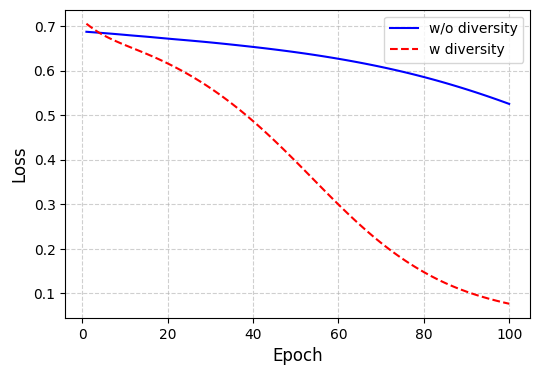

In [16]:
plot_model_comparison_loss(epochs=epochs, losses_a=losses_model_a, losses_b=losses_model_b,
                          model_a_label="w/o diversity",
                          model_b_label="w diversity",
                          ylabel="Loss",
                          xlabel="Epoch",
                          save_path="loss_comparison.pdf")